# Notebook 5 — Live Inference Pipeline

**This is the user-facing notebook.** Point it at any Wireshark `.csv` export and it will:
1. Load and validate the capture file
2. Extract the same flow-level features used during training
3. Run the trained model to classify each flow
4. Output a per-flow results table and a visual summary

## How to export from Wireshark
1. Capture your traffic in Wireshark
2. Go to **File → Export Packet Dissections → As CSV...**
3. Make sure these columns are included: `No.`, `Time`, `Source`, `Destination`, `Protocol`, `Length`, `Info`
4. Set `CAPTURE_CSV` below to the path of your exported file

In [21]:
import sys
import json
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, str(Path('.').resolve()))
from utils.feature_engineering import (
    preprocess_packets,
    extract_flow_features,
    FEATURE_COLS,
    MIN_PACKETS_PER_FLOW,
    CONFIDENCE_THRESHOLD,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

MODELS_DIR = Path('models')

# ─────────────────────────────────────────────────────────────────
# ↓ SET THIS to your Wireshark CSV export path
CAPTURE_CSV = Path('captures/normalTraffic.csv')
# ─────────────────────────────────────────────────────────────────

print('Inference pipeline ready.')
print(f'Capture file        : {CAPTURE_CSV}')
print(f'Min packets/flow    : {MIN_PACKETS_PER_FLOW}')
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}%')

Inference pipeline ready.
Capture file        : captures\normalTraffic.csv
Min packets/flow    : 5
Confidence threshold: 80.0%


## 1. Load trained model artifacts

In [22]:
model    = joblib.load(MODELS_DIR / 'best_model.pkl')
scaler   = joblib.load(MODELS_DIR / 'scaler.pkl')
le       = joblib.load(MODELS_DIR / 'label_encoder.pkl')

with open(MODELS_DIR / 'model_metadata.json') as f:
    meta = json.load(f)

print(f'Model      : {meta["best_model"]}')
print(f'Accuracy   : {meta["best_accuracy"]*100:.2f}%')
print(f'Classes    : {meta["classes"]}')
print(f'Features   : {FEATURE_COLS}')

Model      : XGBoost
Accuracy   : 99.48%
Classes    : ['Benign', 'Brute_Force', 'Exploit', 'Flood', 'Malware', 'Probe']
Features   : ['packet_count', 'avg_length', 'std_length', 'min_length', 'max_length', 'avg_iat', 'std_iat', 'duration', 'bytes_per_second', 'packets_per_second', 'syn_count', 'ack_count', 'fin_count', 'rst_count', 'http_request_count', 'http_response_count', 'unique_dst_ports', 'protocol_encoded']


## 2. Load & validate Wireshark CSV

In [23]:
REQUIRED_COLS = {'No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info'}

def load_wireshark_csv(path: Path) -> pd.DataFrame:
    """Load a Wireshark CSV export with fallback encodings and column validation."""
    if not path.exists():
        raise FileNotFoundError(
            f'File not found: {path}\n'
            'Export from Wireshark via: File → Export Packet Dissections → As CSV'
        )

    # Try common encodings
    df = None
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False)
            break
        except Exception:
            continue

    if df is None:
        raise ValueError(f'Could not read {path} with any encoding.')

    # Validate columns (case-insensitive)
    found = {c.strip() for c in df.columns}
    # Try to match even if the column names differ slightly
    missing = [r for r in REQUIRED_COLS
               if not any(r.lower() in f.lower() for f in found)]
    if missing:
        raise ValueError(
            f'Missing expected columns: {missing}\n'
            f'Found columns: {list(df.columns)}\n'
            'Make sure to export with all columns from Wireshark.'
        )

    return df


raw_capture = load_wireshark_csv(CAPTURE_CSV)
print(f'Loaded capture: {len(raw_capture):,} packets')
print(f'Columns: {raw_capture.columns.tolist()}')
raw_capture.head(5)

Loaded capture: 26,755 packets
Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']


,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,192.168.0.102,140.82.113.25,TCP,55,61436 > 443 [ACK] Seq=1 Ack=1 Win=251 Len=1 ...
1,2,0.557445,192.168.0.102,8.8.8.8,TCP,55,64441 > 443 [ACK] Seq=1 Ack=1 Win=253 Len=1 ...
2,3,2.089489,172.66.154.160,192.168.0.102,TLSv1.2,82,Application Data
3,4,2.092959,192.168.0.102,142.251.223.142,TCP,55,59670 > 443 [ACK] Seq=1 Ack=1 Win=252 Len=1
4,5,2.138956,192.168.0.102,172.66.154.160,TCP,54,63968 > 443 [ACK] Seq=1 Ack=29 Win=255 Len=0


## 3. Preprocess & extract flow features

Uses **identical** logic to Notebook 3 via `utils/feature_engineering.py`.

In [24]:
print('Step 1/3: Preprocessing packets...')
preprocessed = preprocess_packets(raw_capture)
print(f'  {len(preprocessed):,} packets after cleaning')

print('Step 2/3: Extracting flow features...')
# No label_col — inference mode
flows = extract_flow_features(preprocessed, label_col=None)
print(f'  {len(flows):,} flows extracted')

# micro-flow filter is now applied inside extract_flow_features automatically
# (MIN_PACKETS_PER_FLOW = {MIN_PACKETS_PER_FLOW} packets minimum)
if len(flows) == 0:
    raise SystemExit(f'No flows met the minimum threshold of {MIN_PACKETS_PER_FLOW} packets. '
                     'Try lowering MIN_PACKETS_PER_FLOW in utils/feature_engineering.py')
print(f'  {len(flows):,} flows after micro-flow filter')

print('Step 3/3: Scaling features...')
X_live = flows[FEATURE_COLS].copy()
X_live_scaled = scaler.transform(X_live)
print('  Done!')

Step 1/3: Preprocessing packets...
  26,755 packets after cleaning
Step 2/3: Extracting flow features...
    Dropped 593 micro-flows (< 5 packets)
  349 flows extracted
  349 flows after micro-flow filter
Step 3/3: Scaling features...
  Done!


## 4. Run predictions

In [25]:
y_pred_encoded = model.predict(X_live_scaled)
y_pred_labels  = le.inverse_transform(y_pred_encoded)
y_pred_proba   = model.predict_proba(X_live_scaled)
confidence     = y_pred_proba.max(axis=1) * 100  # as percentage

results = flows.copy()
results['raw_prediction'] = y_pred_labels   # what the model actually predicted
results['confidence']     = confidence.round(1)

# Apply confidence threshold — demote uncertain predictions to Benign
# This prevents the model from confidently mislabelling unseen traffic patterns
results['prediction'] = results.apply(
    lambda r: r['raw_prediction'] if r['confidence'] >= CONFIDENCE_THRESHOLD else 'Benign',
    axis=1
)

demoted = (results['raw_prediction'] != results['prediction']).sum()
print(f'Classified {len(results):,} flows')
print(f'Demoted to Benign (confidence < {CONFIDENCE_THRESHOLD}%): {demoted} flows')
results[['flow_id','packet_count','duration','packets_per_second',
          'raw_prediction','prediction','confidence']].head(10)


Classified 349 flows
Demoted to Benign (confidence < 80.0%): 1 flows


,flow_id,packet_count,duration,packets_per_second,raw_prediction,prediction,confidence
0,1991836,12,2.581532,4.648403,Benign,Benign,97.599998
1,2424852,9,1.875752,4.798076,Benign,Benign,99.800003
2,3152125,11,1.677900,6.555814,Benign,Benign,100.000000
3,5808409,6,0.906387,6.619689,Benign,Benign,100.000000
4,8961966,8,1.333852,5.997667,Benign,Benign,100.000000
5,12194074,6,0.108535,55.281706,Benign,Benign,100.000000
6,16130962,24,0.736447,32.588903,Benign,Benign,99.699997
7,20422818,199,1.603865,124.075281,Benign,Benign,99.800003
8,21731704,8,1.561257,5.124076,Benign,Benign,100.000000
9,24490375,47,0.914695,51.383248,Benign,Benign,99.000000


## 5. Summary report

In [26]:
def build_summary(pred_col):
    return (
        results.groupby(pred_col)
        .agg(flow_count=('flow_id','count'),
             avg_confidence=('confidence','mean'),
             avg_packets=('packet_count','mean'))
        .reset_index().rename(columns={pred_col: 'prediction'})
        .assign(pct_of_flows=lambda df: (df['flow_count'] / len(results) * 100).round(2))
        .sort_values('flow_count', ascending=False)
    )

summary_filtered = build_summary('prediction')
summary_raw      = build_summary('raw_prediction')

print('=' * 65)
print('  NETWORK ANOMALY DETECTION — ANALYSIS SUMMARY')
print('=' * 65)
print(f'  Capture file      : {CAPTURE_CSV.name}')
print(f'  Total packets     : {len(raw_capture):,}')
print(f'  Flows classified  : {len(results):,}')
print(f'  Confidence cutoff : {CONFIDENCE_THRESHOLD}%  ({demoted} flows demoted to Benign)')
print()
print('  AFTER confidence threshold (use this):')
print(summary_filtered.to_string(index=False))
print()
print('  RAW model output (before threshold, for reference):')
print(summary_raw.to_string(index=False))
print('=' * 65)

benign_pct  = summary_filtered.loc[summary_filtered['prediction']=='Benign','pct_of_flows'].sum()
anomaly_pct = 100 - benign_pct
if anomaly_pct > 5:
    print(f'\n⚠️  {anomaly_pct:.1f}% of flows classified as ANOMALOUS')
else:
    print(f'\n✅ Traffic looks mostly clean ({benign_pct:.1f}% Benign)')


  NETWORK ANOMALY DETECTION — ANALYSIS SUMMARY
  Capture file      : normalTraffic.csv
  Total packets     : 26,755
  Flows classified  : 349
  Confidence cutoff : 80.0%  (1 flows demoted to Benign)

  AFTER confidence threshold (use this):
prediction  flow_count  avg_confidence  avg_packets  pct_of_flows
    Benign         349       98.910034    73.616046         100.0

  RAW model output (before threshold, for reference):
prediction  flow_count  avg_confidence  avg_packets  pct_of_flows
    Benign         348       99.016380    73.801724         99.71
   Malware           1       61.900002     9.000000          0.29

✅ Traffic looks mostly clean (100.0% Benign)


## 6. Visualise results

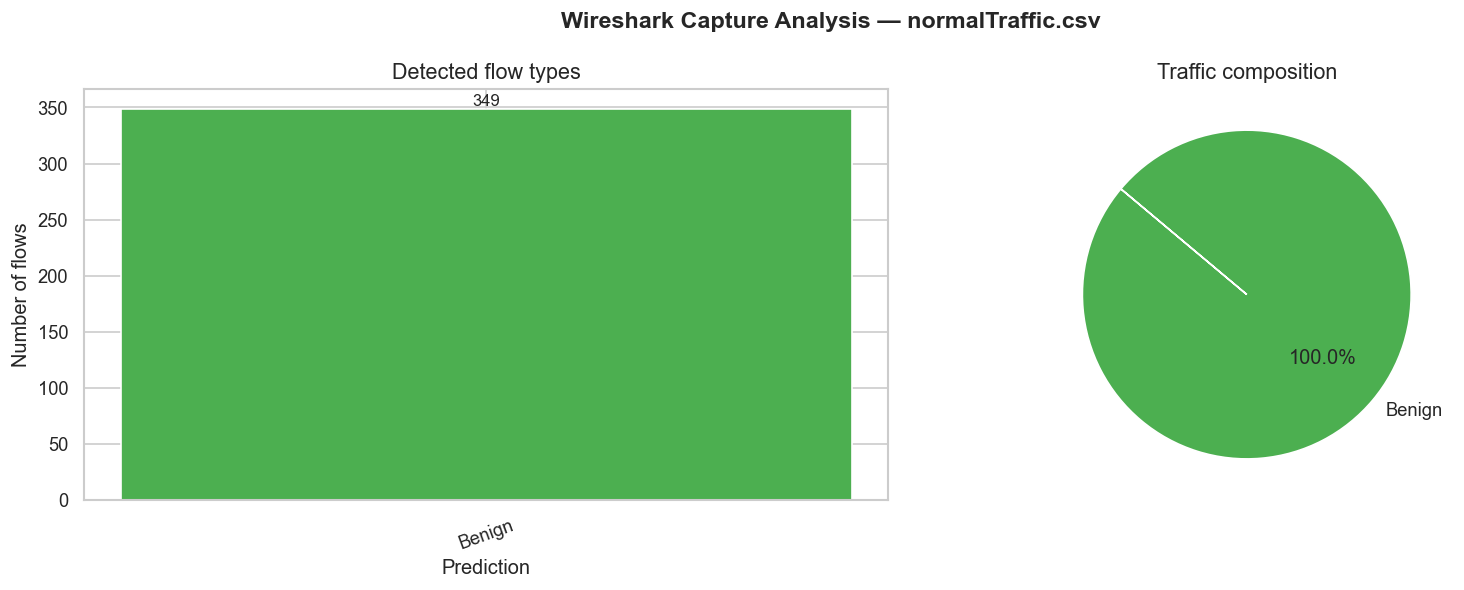

Chart saved as: analysis_normalTraffic.png


In [27]:
# Colour map: Benign = green, everything else = shades of red/orange
all_classes = meta['classes']
color_map = {
    'Benign':      '#4CAF50',
    'Flood':       '#F44336',
    'Malware':     '#9C27B0',
    'Brute_Force': '#FF9800',
    'Exploit':     '#F50057',
    'Probe':       '#2196F3',
}
default_color = '#607D8B'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: flow counts ---
bars = axes[0].bar(
    summary_filtered['prediction'],
    summary_filtered['flow_count'],
    color=[color_map.get(p, default_color) for p in summary_filtered['prediction']]
)
axes[0].set_title('Detected flow types', fontsize=13)
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Number of flows')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0].annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# --- Pie chart: percentage breakdown ---
pie_colors = [color_map.get(p, default_color) for p in summary_filtered['prediction']]
axes[1].pie(
    summary_filtered['flow_count'],
    labels=summary_filtered['prediction'],
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140
)
axes[1].set_title('Traffic composition', fontsize=13)

plt.suptitle(
    f'Wireshark Capture Analysis — {CAPTURE_CSV.name}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'analysis_{CAPTURE_CSV.stem}.png', dpi=150)
plt.show()
print(f'Chart saved as: analysis_{CAPTURE_CSV.stem}.png')

## 6b. Confidence score distribution

Shows how confident the model is per class. Flows left of the red line were demoted to Benign.

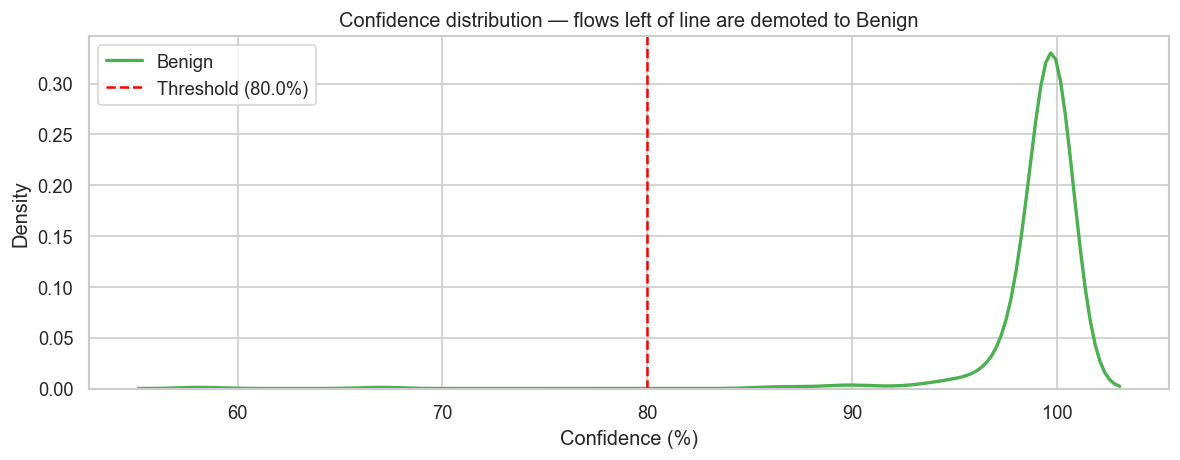

In [28]:
COLOR_MAP = {
    'Benign':'#4CAF50','Flood':'#F44336','Malware':'#9C27B0',
    'Brute_Force':'#FF9800','Exploit':'#F50057','Probe':'#2196F3',
}

fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in results.groupby('raw_prediction'):
    if len(grp) > 1:
        import seaborn as sns
        sns.kdeplot(grp['confidence'], ax=ax, label=label, fill=False,
                    linewidth=2, color=COLOR_MAP.get(label, '#607D8B'))
ax.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold ({CONFIDENCE_THRESHOLD}%)')
ax.set_title('Confidence distribution — flows left of line are demoted to Benign')
ax.set_xlabel('Confidence (%)'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout()
plt.savefig(f'confidence_{CAPTURE_CSV.stem}.png', dpi=150)
plt.show()


## 7. Per-flow detail table

Full breakdown of every flow with its prediction and confidence score.

In [29]:
detail_cols = [
    'flow_id', 'packet_count', 'duration', 'avg_length',
    'packets_per_second', 'bytes_per_second',
    'syn_count', 'ack_count', 'http_request_count',
    'prediction', 'confidence'
]

detail = results[detail_cols].sort_values('confidence', ascending=False)
detail = detail.round(3)

# Save to CSV for further analysis
out_csv = f'results_{CAPTURE_CSV.stem}.csv'
detail.to_csv(out_csv, index=False)
print(f'Per-flow results saved to: {out_csv}')
print(f'\nTop 10 highest-confidence flows:')
detail.head(10)

Per-flow results saved to: results_normalTraffic.csv

Top 10 highest-confidence flows:


,flow_id,packet_count,duration,avg_length,packets_per_second,bytes_per_second,syn_count,ack_count,http_request_count,prediction,confidence
347,998896916,10,1.097,1123.400,9.119,10244.532,0,0,0,Benign,100.0
345,995673449,11,3.142,706.000,3.501,2471.439,0,0,0,Benign,100.0
2,3152125,11,1.678,376.909,6.556,2470.946,0,0,0,Benign,100.0
3,5808409,6,0.906,524.667,6.620,3473.130,0,6,0,Benign,100.0
4,8961966,8,1.334,60.000,5.998,359.860,0,8,0,Benign,100.0
5,12194074,6,0.109,416.833,55.282,23043.258,0,0,0,Benign,100.0
306,893537488,10,1.533,203.700,6.521,1328.340,0,0,0,Benign,100.0
325,952085321,7,0.115,864.714,61.011,52756.811,0,0,0,Benign,100.0
318,926555430,8,0.134,1138.375,59.919,68210.075,0,0,0,Benign,100.0
314,917069113,7,2.516,610.286,2.783,1698.219,0,0,0,Benign,100.0


## 8. Suspicious flows deep-dive

Filter to show only non-Benign flows for investigation.

In [30]:
detail_cols = [
    'flow_id', 'packet_count', 'duration', 'avg_length',
    'packets_per_second', 'bytes_per_second',
    'syn_count', 'ack_count', 'http_request_count',
    'raw_prediction', 'prediction', 'confidence'
]

detail = results[detail_cols].sort_values('confidence', ascending=False).round(3)
out_csv = f'results_{CAPTURE_CSV.stem}.csv'
detail.to_csv(out_csv, index=False)
print(f'Full results saved: {out_csv}')

suspicious = detail[detail['prediction'] != 'Benign']
if len(suspicious) == 0:
    print('\n✅ No suspicious flows detected.')
else:
    print(f'\n⚠️  {len(suspicious)} suspicious flows:')
    print(suspicious.to_string(index=False))


Full results saved: results_normalTraffic.csv

✅ No suspicious flows detected.


## ✅ Inference complete!

**Outputs:**
- `analysis_<filename>.png` — visual breakdown chart
- `results_<filename>.csv` — per-flow results table

**Interpreting results:**
| Class | What it means |
|---|---|
| `Benign` | Normal network traffic |
| `Flood` | Volume-based DoS attack (SYN/UDP/HTTP/ICMP flood) |
| `Malware` | Malicious software communication (ransomware, trojan, spyware) |
| `Brute_Force` | Repeated login/auth attempts |
| `Exploit` | Vulnerability exploitation attempt |
| `Probe` | Network scanning / reconnaissance |